In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

quiz_data = pd.DataFrame({
  "study_hours":
    [4.8, 11.4, 8.9, 7.4, 2.3, 2.3, 1.2, 10.5, 7.4, 8.6, 0.7, 11.7, 10.1, 2.9, 2.6, 2.6, 4.0, 6.5, 5.5, 3.8, 7.5, 2.1,
     3.9, 4.7, 5.7, 9.5, 2.8, 6.4, 7.3, 1.0, 7.5, 2.5, 1.2, 11.4, 11.6, 9.8, 4.0, 1.6, 8.4, 5.6, 1.9, 6.2, 0.9, 11.0,
     3.5, 8.1, 4.1, 6.5, 6.8, 2.6, 11.7, 9.4, 11.3, 10.8, 7.4, 11.1, 1.5, 2.8, 1.0, 4.2],
  "videos_watched":
    [15, 12, 17, 14, 20, 23, 24, 12, 8, 14, 12, 0, 24, 6, 8, 23, 0, 11, 7, 23, 10, 18, 16, 7, 2, 2, 0, 4, 9, 6, 8, 6, 8,
     7, 11, 1, 0, 15, 22, 22, 23, 4, 2,
     11, 7, 21, 2, 0, 2, 4, 14, 13, 2, 0, 4, 22, 13, 6, 8, 14],
  "practice_solved":
    [14, 25, 12, 31, 38, 31, 3, 29, 36, 22, 38, 14, 28, 35, 12, 31, 6, 21, 27, 1, 5, 27, 27, 19, 29, 10, 27, 24, 38, 32,
     0, 26, 12, 2, 38, 5, 7, 26
      , 8, 36, 32, 23, 14, 31, 31, 23, 11, 38, 1, 2, 36, 16, 1, 1, 27, 22, 36, 31, 32, 0],
  "quiz_score":
    [59.7, 94.2, 82.2, 83.1, 72.2, 62.8, 43.3, 97.3, 78.1, 88.6, 61.2, 86.6, 97.9, 59.2, 43.3, 72.4, 48.4, 74.1, 66.6,
     54.6, 67.3, 55.2, 68.7, 54.5, 67.1, 69.7, 47.2, 62.9, 81.4, 50.7, 64.3, 53.8, 44.5, 88.3, 100.0, 67.1, 36.4, 59.6,
     85.4, 80.9, 68.6, 69.8, 35.0, 100.0, 60.6, 82.2, 50.8, 77.4, 55.7, 32.3, 100.0, 77.8, 76.1, 74.3, 74.4, 100.0,
     55.3, 56.6, 44.6, 47.0]
})

In [2]:
# 1

In [3]:
X = quiz_data.iloc[:, :-1]
y = quiz_data.iloc[:, -1]

# print(X.shape, y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42,  test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
LR = LinearRegression()
LR.fit(X_train, y_train)
y_pred = LR.predict(X_test)
print(LR.score(X_test, y_test))

0.9445055055831496


In [4]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"r2 score: {r2}")
print(f"mean squared error: {mse}")
print(f"mean absolute error: {mae}")


r2 score: 0.9445055055831496
mean squared error: 19.961307981191737
mean absolute error: 3.5647757861145473


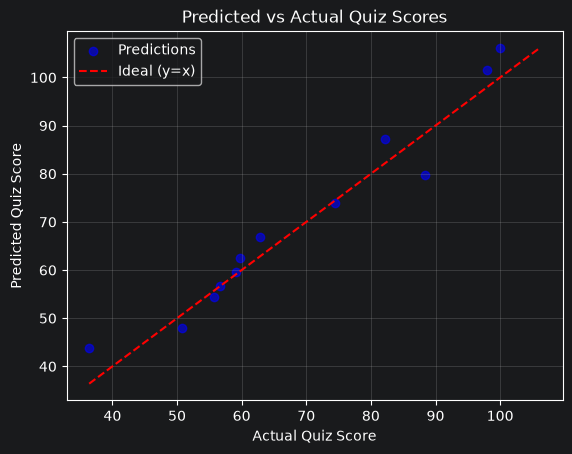

In [5]:
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predictions')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal (y=x)')

plt.xlabel('Actual Quiz Score')
plt.ylabel('Predicted Quiz Score')
plt.title('Predicted vs Actual Quiz Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
features = X.columns.tolist()
coefficients = LR.coef_
for feature, coef in zip(features, coefficients):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {LR.intercept_:.4f}")

study_hours: 16.1348
videos_watched: 5.3153
practice_solved: 7.2751
Intercept: 67.6104
